In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, root_mean_squared_error

import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

## Mounting to Google Drive

### Uncomment if utilizing Google Colab

In [3]:
colab = True

In [5]:
path = os.getcwd()
print(path)
if colab:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir("./drive/My Drive/TreatmentSystems/Final_Dataset")
else:
    os.chdir(os.path.join(path, 'Final_Dataset'))

print(os.getcwd())

/content
Mounted at /content/drive
/content/drive/My Drive/TreatmentSystems/Final_Dataset


### Receiving Data and Completing Train-Test Split

In [6]:
data = pd.read_csv('concatenated_data.csv')
print(type(data))
print(data.head())

# is_sorted = data.equals(data.sort_values(by=['PatientID', 'time']).reset_index(drop=True))
# print("Data is sorted correctly:", is_sorted)
times = data.pop('time')

data.head()

numPatients = data['PatientID'].max()
print(numPatients)

<class 'pandas.core.frame.DataFrame'>
               time  PatientID  calories  heart_rate  steps  basal_rate  \
0  06-13-2018 18:40          1    6.3595   82.322835     34    0.091667   
1  06-13-2018 18:45          1    7.7280   83.740157      0    0.091667   
2  06-13-2018 18:50          1    4.7495   80.525180      0    0.091667   
3  06-13-2018 18:55          1    6.3595   89.129032     20    0.091667   
4  06-13-2018 19:00          1    5.1520   92.495652      0    0.075000   

   bolus_volume_delivered  glucose  
0                     0.0    332.0  
1                     0.0    326.0  
2                     0.0    330.0  
3                     0.0    324.0  
4                     0.0    306.0  
22


In [7]:
print((data['basal_rate'] >= 0).all() and (data['basal_rate'] <= 1).all())

True


In [8]:
print((data['bolus_volume_delivered'] >= 0).all() and (data['bolus_volume_delivered'] <= 1).all())

False


In [ ]:
train_patients = list(range(1, 17))
print(len(train_patients))
print(train_patients)

test_patients = list(range(17, numPatients + 1))
print(len(test_patients))
print(test_patients)

train_data = data[data['PatientID'].isin(train_patients)]
test_data = data[data['PatientID'].isin(test_patients)]

print("\n Training Data:")
train_X, train_y = train_data.loc[:, data.columns != 'glucose'], train_data['glucose']
print(train_X.head())
print(train_y.head())

train_len = len(train_X)
N = len(data)
print(train_len, N)
train_percent = (train_len / N)

print("Percent of Data in Training = ", np.round(train_percent * 100, 2))
print("\n Testing Data:")
test_X, test_y = test_data.loc[:, data.columns != 'glucose'], test_data['glucose']
print(test_X.head())
print(test_y.head())

print("Percent of Data in Testing = ", np.round((1 - train_percent) * 100, 2))

16
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
6
[17, 18, 19, 20, 21, 22]

 Training Data:
   PatientID  calories  heart_rate  steps  basal_rate  bolus_volume_delivered
0          1    6.3595   82.322835     34    0.091667                     0.0
1          1    7.7280   83.740157      0    0.091667                     0.0
2          1    4.7495   80.525180      0    0.091667                     0.0
3          1    6.3595   89.129032     20    0.091667                     0.0
4          1    5.1520   92.495652      0    0.075000                     0.0
0    332.0
1    326.0
2    330.0
3    324.0
4    306.0
Name: glucose, dtype: float64
46080 63360
Percent of Data in Training =  72.73

 Testing Data:
       PatientID  calories  heart_rate  steps  basal_rate  \
46080         17   15.0429   96.371901      8       0.035   
46081         17    8.3164   91.395349      0       0.035   
46082         17    7.5826   85.991935      0       0.035   
46083         17    7.3380   82.434

### Scale the Features Before Training

#### Columns That Needed to Be Scaled:
- Calories
- Steps
- Heart Rate
- Glucose

Possibly Need to Scale the Basal Rate -> First Attempt will be without scaling the Basal

Note that Glucose Needs to be converted back to the original values before the scaling in order to interpret the results

In [ ]:
print("Calories:")
print("Min = ", train_X['calories'].min())
print("Max = ", train_X['calories'].max())
print(len(np.where(train_X['calories'].max())))

print("Heart Rate:")
print("Min = ", train_X['heart_rate'].min())
print("Max = ", train_X['heart_rate'].max())
print(len(np.where(train_X['heart_rate'].max())))

print("Steps:")
print("Min = ", train_X['steps'].min())
print("Max = ", train_X['steps'].max())
print(len(np.where(train_X['steps'].max())))

print("Basal Rate:")
print("Min = ", train_X['basal_rate'].min())
print("Max = ", train_X['basal_rate'].max())
print(len(np.where(train_X['basal_rate'].max())))

Calories:
Min =  4.025000036
Max =  78.85771084
1
Heart Rate:
Min =  39.38406616
Max =  174.7142857
1
Steps:
Min =  0
Max =  658
1
Basal Rate:
Min =  0.0
Max =  0.25
1


C:\Users\nwalr\AppData\Local\Temp\ipykernel_55424\969163671.py:4: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(arr).nonzero()` if the old behavior was intended.
  print(len(np.where(train_X['calories'].max())))
C:\Users\nwalr\AppData\Local\Temp\ipykernel_55424\969163671.py:9: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(arr).nonzero()` if the old behavior was intended.
  print(len(np.where(train_X['heart_rate'].max())))
C:\Users\nwalr\AppData\Local\Temp\ipykernel_55424\969163671.py:14: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(arr).nonzero()` if the old behavior was intended.
  print(len(np.where(train_X['steps'].max())))
C:\Users\nwalr\AppData\Local\Temp\ipykernel_55424\969163671.py:19: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(arr

In [34]:
scaler1_x = MinMaxScaler(feature_range=(-1, 1))
scaler1_y = MinMaxScaler()

In [ ]:
column_names = data.columns
print(column_names[-3:-1])
print(column_names[:1])
print(column_names[1:data.shape[1] - 3])
# standardize_features = list(column_names[1:data.shape[1] - 3]) # Features to standardize
# passthrough_features = list(column_names[-3:-1]) # Keep these unchanged
# print(standardize_features, passthrough_features)

# Define ColumnTransformer

train_X_scaled = scaler1_x.fit_transform(np.array(train_X)[:, 1:6])
test_X_scaled = scaler1_x.transform(np.array(test_X)[:, 1:6])

print(train_X_scaled[:5], type(train_X_scaled))
print(test_X_scaled[:5], type(test_X_scaled))

In [ ]:
print("Glucose")
print("Min = ", train_y.min())
print("Max = ", train_y.max())

In [ ]:
train_y_scaled = scaler1_y.fit_transform(np.array(train_y).reshape(-1, 1))
test_y_scaled = scaler1_y.transform(np.array(test_y).reshape(-1, 1))

print(train_y_scaled[:5])
print(test_y_scaled[:5])

In [ ]:
sequence_length, batch_size = 50, 64
n_features = 5
stride = 1

train_gen = TimeseriesGenerator(train_X_scaled, train_y_scaled, length=sequence_length, batch_size = batch_size, stride = stride)
test_gen = TimeseriesGenerator(test_X_scaled, test_y_scaled, length=sequence_length, batch_size=batch_size, stride = stride)

In [ ]:
print(type(train_gen))
print(type(test_gen))

print(len(train_gen))
print(train_gen[0])

x, y = train_gen[0]

print(x.shape)
print(y.shape)

In [ ]:
model1 = Sequential()
model1.add(LSTM(100, activation='relu', input_shape=(sequence_length, n_features)))
model1.add(Dense(1))

adam_opt = keras.optimizers.Adam(learning_rate=1e-3)
model1.compile(loss='mse', optimizer = adam_opt)

# fit model
history = model1.fit(train_gen, validation_data=test_gen, epochs = 50, verbose=2)

preds = model1.predict(test_gen)
y_true = test_y_scaled[sequence_length:]

y_pred_original = scaler1_y.inverse_transform(preds)
y_true_original = scaler1_y.inverse_transform(y_true.reshape(-1, 1))

In [ ]:
print(y_pred_original)
print(y_true_original)

print("R2 Score = ", r2_score(y_true_original, y_pred_original))

### Creation of Plots for Visualizations

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

#### Model 2: Deep LSTM with Dropout

In [ ]:
model2 = Sequential()
#Layer 1
model2.add(LSTM(256, activation='relu', return_sequences= True, input_shape=(sequence_length, n_features)))
model2.add(Dropout(0.3))

#Layer 2
model2.add(LSTM(128, activation = 'relu', return_sequences=True))
model2.add(Dropout(0.25))

#Layer 2
model2.add(LSTM(64, activation = 'relu', return_sequences=True))
model2.add(Dropout(0.2))

#Layer 2
model2.add(LSTM(32, activation = 'relu', return_sequences=True))
model2.add(Dropout(0.15))

#Layer 2
model2.add(LSTM(16, activation = 'relu', return_sequences=True))
model2.add(Dropout(0.1))

model2.add(Dense(1))

adam_opt = keras.optimizers.Adam(learning_rate=0.001)
model2.compile(loss='mse', optimizer = adam_opt)

# fit model
history2 = model2.fit(train_gen, validation_data=test_gen, epochs = 100, verbose=2, shuffle = False)

preds = model2.predict(test_gen)
preds = preds.reshape(-1, 1)
y_true = test_y_scaled[sequence_length:]

y_pred_original = scaler1_y.inverse_transform(preds)
y_true_original = scaler1_y.inverse_transform(y_true.reshape(-1, 1))

In [ ]:
print(y_pred_original)
print(y_true_original)

print("R2 Score = ", r2_score(y_true_original, y_pred_original))

In [ ]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

#### Scalar Modifications

Add MaxAbsScalar for the Bolus Insulin Feature since it is sparse

In [ ]:
column_names = data.columns
print(column_names[-3:-1])
print(column_names[1:data.shape[1] - 2])
standardize_features = list(column_names[1:data.shape[1] - 2]) # standardize using MinMax Scalar
sparse_features = list(column_names[-2:-1]) #
print(column_names[-2:-1])
# print(standardize_features, passthrough_features)

# Define ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('minmax', MinMaxScaler(), standardize_features),  # Apply MinMaxScaler
        ('maxabs', MaxAbsScaler(), sparse_features)
    ]
)

train_X_scaled = preprocessor.fit_transform(train_X)
test_X_scaled = preprocessor.transform(test_X)

print(train_X_scaled[30:45], type(train_X_scaled))
print(test_X_scaled[30:45], type(test_X_scaled))

In [ ]:
train_y_scaled = scaler1_y.fit_transform(np.array(train_y).reshape(-1, 1))
test_y_scaled = scaler1_y.transform(np.array(test_y).reshape(-1, 1))

print(train_y_scaled[:5])
print(test_y_scaled[:5])

In [ ]:
sequence_length, batch_size = 50, 64
n_features = 5
stride = 1

train_gen = TimeseriesGenerator(train_X_scaled, train_y_scaled, length=sequence_length, batch_size = batch_size, stride = stride)
test_gen = TimeseriesGenerator(test_X_scaled, test_y_scaled, length=sequence_length, batch_size=batch_size, stride = stride)

In [ ]:
print(type(train_gen))
print(type(test_gen))

print(len(train_gen))
print(train_gen[0])

x, y = train_gen[0]

print(x.shape)
print(y.shape)

In [ ]:
model3 = Sequential()
model3.add(LSTM(100, activation='relu', input_shape=(sequence_length, n_features)))
model3.add(Dense(1))

adam_opt = keras.optimizers.Adam(learning_rate=1e-3)
model3.compile(loss='mse', optimizer = adam_opt)

# fit model
history3 = model1.fit(train_gen, validation_data=test_gen, epochs = 50, verbose=2)

preds = model1.predict(test_gen)
y_true = test_y_scaled[sequence_length:]

y_pred_original = scaler1_y.inverse_transform(preds)
y_true_original = scaler1_y.inverse_transform(y_true.reshape(-1, 1))

print(y_pred_original)
print(y_true_original)

print("R2 Score = ", r2_score(y_true_original, y_pred_original))

In [ ]:
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
model4 = Sequential()
#Layer 1
model4.add(LSTM(256, activation='relu', return_sequences= True, input_shape=(sequence_length, n_features)))
model4.add(Dropout(0.3))

#Layer 2
model4.add(LSTM(128, activation = 'relu', return_sequences=True))
model4.add(Dropout(0.25))

#Layer 2
model4.add(LSTM(64, activation = 'relu', return_sequences=True))
model4.add(Dropout(0.2))

#Layer 2
model4.add(LSTM(32, activation = 'relu', return_sequences=True))
model4.add(Dropout(0.15))

#Layer 2
model4.add(LSTM(16, activation = 'relu', return_sequences=True))
model4.add(Dropout(0.1))

model4.add(Dense(1))

adam_opt = keras.optimizers.Adam(learning_rate=0.001)
model4.compile(loss='mse', optimizer = adam_opt)

# fit model
history4 = model2.fit(train_gen, validation_data=test_gen, epochs = 100, verbose=2, shuffle = False)

preds = model4.predict(test_gen)
preds = preds.reshape(-1, 1)
y_true = test_y_scaled[sequence_length:]

y_pred_original = scaler1_y.inverse_transform(preds)
y_true_original = scaler1_y.inverse_transform(y_true.reshape(-1, 1))

print(y_pred_original)
print(y_true_original)

print("R2 Score = ", r2_score(y_true_original, y_pred_original))

In [ ]:
plt.plot(history4.history['loss'])
plt.plot(history4.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

### Approach 3:

In [9]:
from sklearn.model_selection import train_test_split

unique_patients = data['PatientID'].unique()
train_patients, test_patients = train_test_split(unique_patients, test_size=0.2, random_state=42)

print(train_patients)
print(test_patients)

train_df = data[data['PatientID'].isin(train_patients)].copy()
print(train_df)
test_df = data[data['PatientID'].isin(test_patients)].copy()

[ 6 21 12  4  5 18 13 19 17  3 10 22  8 11 15 20  7]
[ 1 14  9  2 16]
       PatientID  calories  heart_rate  steps  basal_rate  \
5760           3   7.32088   70.692308      8       0.075   
5761           3  11.19664   90.333333     17       0.075   
5762           3   8.18216   84.677419      0       0.075   
5763           3   8.82812   89.727273      8       0.075   
5764           3   6.67492   91.235294      0       0.075   
...          ...       ...         ...    ...         ...   
63355         22   5.93604   71.532258     15       0.000   
63356         22   4.58694   74.097561      0       0.000   
63357         22   4.85676   72.763158      0       0.000   
63358         22   8.54430   83.344828     23       0.000   
63359         22   4.67688   75.634146      0       0.000   

       bolus_volume_delivered     glucose  
5760                      0.0  137.666667  
5761                      0.0  137.000000  
5762                      0.0  136.333333  
5763                 

In [15]:
column_names = data.columns
print(column_names)
print(column_names[-3:-1])
print(column_names[1:data.shape[1] - 2])
standardize_features = list(column_names[1:data.shape[1] - 2]) # standardize using MinMax Scalar
sparse_features = list(column_names[-2:-1]) #
print(column_names[-2:-1])
feature_columns = standardize_features + sparse_features
# print(standardize_features, passthrough_features)

# Define ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('minmax', MinMaxScaler(), standardize_features),  # Apply MinMaxScaler
        ('maxabs', MaxAbsScaler(), sparse_features)
    ]
)

preprocessor.fit(train_df[feature_columns])

train_df[feature_columns] = preprocessor.transform(train_df[feature_columns])
test_df[feature_columns] = preprocessor.transform(test_df[feature_columns])

scaler1_y = MinMaxScaler()
scaler1_y.fit(np.array(train_df['glucose']).reshape(-1, 1))
train_df['glucose'] = scaler1_y.transform(np.array(train_df['glucose']).reshape(-1, 1))
test_df['glucose'] = scaler1_y.transform(np.array(test_df['glucose']).reshape(-1, 1))

print(train_df['glucose'][:10])
print(test_df['glucose'][:10])

Index(['PatientID', 'calories', 'heart_rate', 'steps', 'basal_rate',
       'bolus_volume_delivered', 'glucose'],
      dtype='object')
Index(['basal_rate', 'bolus_volume_delivered'], dtype='object')
Index(['calories', 'heart_rate', 'steps', 'basal_rate'], dtype='object')
Index(['bolus_volume_delivered'], dtype='object')
5760    0.242049
5761    0.240397
5762    0.238744
5763    0.237092
5764    0.235440
5765    0.233788
5766    0.232135
5767    0.230483
5768    0.218092
5769    0.205700
Name: glucose, dtype: float64
0    0.723668
1    0.708798
2    0.718711
3    0.703841
4    0.659232
5    0.676580
6    0.674102
7    0.627014
8    0.651797
9    0.627014
Name: glucose, dtype: float64


In [16]:
print(train_df)
print(test_df)

       PatientID  calories  heart_rate     steps  basal_rate  \
5760           3  0.068838    0.191853  0.010596        0.45   
5761           3  0.105281    0.318914  0.022517        0.45   
5762           3  0.076936    0.282325  0.000000        0.45   
5763           3  0.083010    0.314993  0.010596        0.45   
5764           3  0.062764    0.324749  0.000000        0.45   
...          ...       ...         ...       ...         ...   
63355         22  0.055816    0.197287  0.019868        0.00   
63356         22  0.043131    0.213882  0.000000        0.00   
63357         22  0.045668    0.205250  0.000000        0.00   
63358         22  0.080341    0.273704  0.030464        0.00   
63359         22  0.043976    0.223823  0.000000        0.00   

       bolus_volume_delivered   glucose  
5760                      0.0  0.242049  
5761                      0.0  0.240397  
5762                      0.0  0.238744  
5763                      0.0  0.237092  
5764                 

In [ ]:
def create_sequences(df, sequence_length, stride=1):
    X, y = [], []
    grouped = df.groupby('PatientID')

    for _, patient_data in grouped:
        patient_features = patient_data.drop(['PatientID', 'glucose'], axis=1).values
        patient_targets = patient_data['glucose'].values

        for i in range(0, len(patient_data) - sequence_length, stride):
            seq_x = patient_features[i:i+sequence_length]
            seq_y = patient_targets[i+sequence_length]
            X.append(seq_x)
            y.append(seq_y)

    print(X, len(X))
    print(y, len(y))
    return np.array(X), np.array(y)

# Set parameters
sequence_length = 30
stride = 5

# Create time-series sequences
train_X, train_y = create_sequences(train_df, sequence_length, stride)
test_X, test_y = create_sequences(test_df, sequence_length, stride)



Streaming output truncated to the last 5000 lines.
       [0.06069958, 0.13784501, 0.        , 0.45      , 0.        ],
       [0.05755994, 0.13436334, 0.        , 0.45      , 0.        ],
       [0.09837518, 0.15761636, 0.05827815, 0.45      , 0.        ],
       [0.07639774, 0.14583569, 0.01192053, 0.45      , 0.        ],
       [0.05546686, 0.10874936, 0.        , 0.45      , 0.        ],
       [0.05337377, 0.10412666, 0.        , 0.8       , 0.        ],
       [0.05337377, 0.11240838, 0.        , 0.8       , 0.        ],
       [0.06907193, 0.11843176, 0.01059603, 0.8       , 0.        ],
       [0.07221157, 0.12841275, 0.01192053, 0.8       , 0.        ],
       [0.07116502, 0.12460619, 0.01854305, 0.8       , 0.        ],
       [0.12349224, 0.17035039, 0.07284768, 0.8       , 0.        ]]), array([[0.05337377, 0.10075967, 0.        , 0.65      , 0.        ],
       [0.05442031, 0.10631976, 0.        , 0.65      , 0.        ],
       [0.05546686, 0.12132099, 0.        , 0.65  

In [19]:
model5 = Sequential()
model5.add(LSTM(50, activation='tanh',input_shape=(train_X.shape[1], train_X.shape[2]), return_sequences=True))
model5.add(Dropout(0.3))
model5.add(LSTM(32, activation='tanh'))
model5.add(Dropout(0.3))
model5.add(Dense(1))

adam_opt = keras.optimizers.Adam(learning_rate=1e-3)
model5.compile(loss='mse', optimizer = adam_opt)

# fit model
history5 = model5.fit(train_X, train_y, epochs = 50, verbose=2)

preds = model5.predict(test_X)

y_pred = scaler1_y.inverse_transform(preds.reshape(-1, 1))
y_true = scaler1_y.inverse_transform(test_y.reshape(-1, 1))

print(y_pred)
print(y_true)

print("R2 Score = ", r2_score(y_true, y_pred))
print("RMSE = ", root_mean_squared_error(y_true, y_pred))

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


303/303 - 4s - 12ms/step - loss: 0.0302
Epoch 2/50
303/303 - 2s - 6ms/step - loss: 0.0283
Epoch 3/50
303/303 - 2s - 8ms/step - loss: 0.0279
Epoch 4/50
303/303 - 2s - 8ms/step - loss: 0.0276
Epoch 5/50
303/303 - 2s - 7ms/step - loss: 0.0274
Epoch 6/50
303/303 - 2s - 6ms/step - loss: 0.0271
Epoch 7/50
303/303 - 3s - 8ms/step - loss: 0.0269
Epoch 8/50
303/303 - 3s - 9ms/step - loss: 0.0271
Epoch 9/50
303/303 - 3s - 11ms/step - loss: 0.0268
Epoch 10/50
303/303 - 2s - 6ms/step - loss: 0.0267
Epoch 11/50
303/303 - 2s - 6ms/step - loss: 0.0264
Epoch 12/50
303/303 - 2s - 6ms/step - loss: 0.0263
Epoch 13/50
303/303 - 3s - 8ms/step - loss: 0.0261
Epoch 14/50
303/303 - 2s - 7ms/step - loss: 0.0260
Epoch 15/50
303/303 - 3s - 10ms/step - loss: 0.0259
Epoch 16/50
303/303 - 2s - 6ms/step - loss: 0.0259
Epoch 17/50
303/303 - 2s - 6ms/step - loss: 0.0258
Epoch 18/50
303/303 - 2s - 6ms/step - loss: 0.0256
Epoch 19/50
303/303 - 3s - 8ms/step - loss: 0.0256
Epoch 20/50
303/303 - 2s - 8ms/step - loss: 0.02

RMSE =  0.3278645453697759
[[-0.39703476]
 [-0.50087255]
 [-0.51173097]
 [-0.4932626 ]
 [-0.4827419 ]
 [-0.47903597]
 [-0.4781283 ]
 [-0.46672618]
 [-0.45581865]
 [-0.43402654]]
[[-0.80669145]
 [-0.74225527]
 [-0.69268897]
 [-0.37050805]
 [-0.32094176]
 [-0.62825279]
 [-0.43494424]
 [-0.41511772]
 [-0.5291202 ]
 [-0.29615861]]


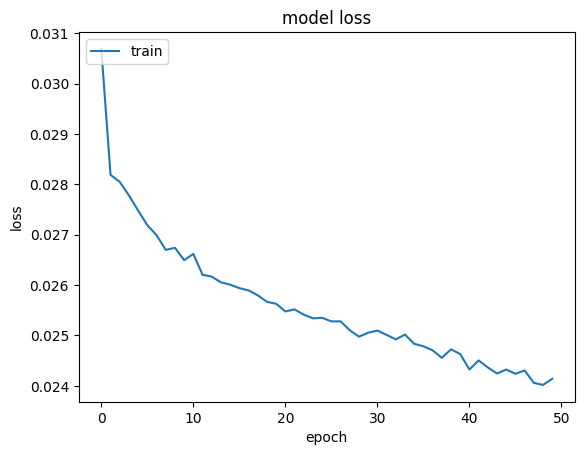

In [51]:
plt.plot(history5.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train'], loc='upper left')
plt.show()